In [1]:
#  NOTEBOOK 07 — EVALUATION METRICS
#  Stage 5: Machine Learning Detection Layer (Evaluation)
#  File: 07_evaluation_metrics.ipynb
# ================================================================
 
# ── CELL 1 ──────────────────────────────────────────────────────
# NOTEBOOK 07 — EVALUATION METRICS
# Stage 5: Machine Learning Detection Layer — Evaluation
# Purpose : Full evaluation on unseen test set
#           Accuracy, Precision, Recall, F1, ROC-AUC,
#           Confusion Matrix, SHAP explainability
# Input   : xgboost_model.pkl + test_data.pkl
# Output  : All evaluation plots + classification_report.txt
 

In [3]:
# ── CELL 2 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve,
                             classification_report, average_precision_score,
                             precision_recall_curve)
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
 
MODEL_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
PLOT_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
REPORT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'reports'))
 
os.makedirs(REPORT_DIR, exist_ok=True)
 
# Load model and test data
xgb_model = joblib.load(os.path.join(MODEL_DIR, 'xgboost_model.pkl'))
test_data  = joblib.load(os.path.join(MODEL_DIR, 'test_data.pkl'))
 
X_test        = test_data['X_test']
y_test        = test_data['y_test']
feature_names = test_data['feature_names']
 
print(f"Model loaded successfully")
print(f"Test set      : {X_test.shape}")
print(f"Feature names : {feature_names}")
print(f"Classes       : {np.unique(y_test)}")

Model loaded successfully
Test set      : (8790, 33)
Feature names : ['pslist.nproc', 'pslist.avg_threads', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.avg_handles_per_proc', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'malfind.ninjections', 'malfind.commitCharge', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', 'psxview.not_in_session_false_avg', 'psxview.not_in_deskthrd_false_avg', 'modules.nmodules', 'svcscan.kernel_drivers', 'svcscan.fs_drivers', 'svcscan.shared_process_services', 'svcscan.nactive', 'callbacks.ncallbacks', 'callbacks.ngeneric']
Classes       : [0 1]


In [4]:
# ── CELL 3 ──────────────────────────────────────────────────────
# Get predictions and probabilities
y_pred      = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
 
# Calculate all metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary', pos_label=1)
rec  = recall_score(y_test, y_pred, average='binary', pos_label=1)
f1   = f1_score(y_test, y_pred, average='binary', pos_label=1)
auc  = roc_auc_score(y_test, y_pred_prob)
ap   = average_precision_score(y_test, y_pred_prob)
 
print("=" * 55)
print("   XGBOOST EVALUATION RESULTS — TEST SET")
print("=" * 55)
print(f"  Accuracy           : {acc*100:.4f}%")
print(f"  Precision          : {prec*100:.4f}%")
print(f"  Recall (Sensitivity): {rec*100:.4f}%")
print(f"  F1-Score           : {f1*100:.4f}%")
print(f"  ROC-AUC Score      : {auc:.6f}")
print(f"  Avg Precision (AP) : {ap:.6f}")
print("=" * 55)
print(f"\nDetailed Classification Report:")
report = classification_report(y_test, y_pred,
                               target_names=['Benign','Malicious'])
print(report)
 
# Save report
with open(os.path.join(REPORT_DIR, 'classification_report.txt'), 'w') as f:
    f.write("AMRDF — XGBoost Classification Report\n")
    f.write("Dataset: CIC-MalMem-2022\n")
    f.write("="*55 + "\n")
    f.write(f"Accuracy  : {acc*100:.4f}%\n")
    f.write(f"Precision : {prec*100:.4f}%\n")
    f.write(f"Recall    : {rec*100:.4f}%\n")
    f.write(f"F1-Score  : {f1*100:.4f}%\n")
    f.write(f"ROC-AUC   : {auc:.6f}\n")
    f.write("="*55 + "\n\n")
    f.write(report)
print("Saved: classification_report.txt")

   XGBOOST EVALUATION RESULTS — TEST SET
  Accuracy           : 99.9772%
  Precision          : 99.9545%
  Recall (Sensitivity): 100.0000%
  F1-Score           : 99.9773%
  ROC-AUC Score      : 1.000000
  Avg Precision (AP) : 1.000000

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4395
   Malicious       1.00      1.00      1.00      4395

    accuracy                           1.00      8790
   macro avg       1.00      1.00      1.00      8790
weighted avg       1.00      1.00      1.00      8790

Saved: classification_report.txt


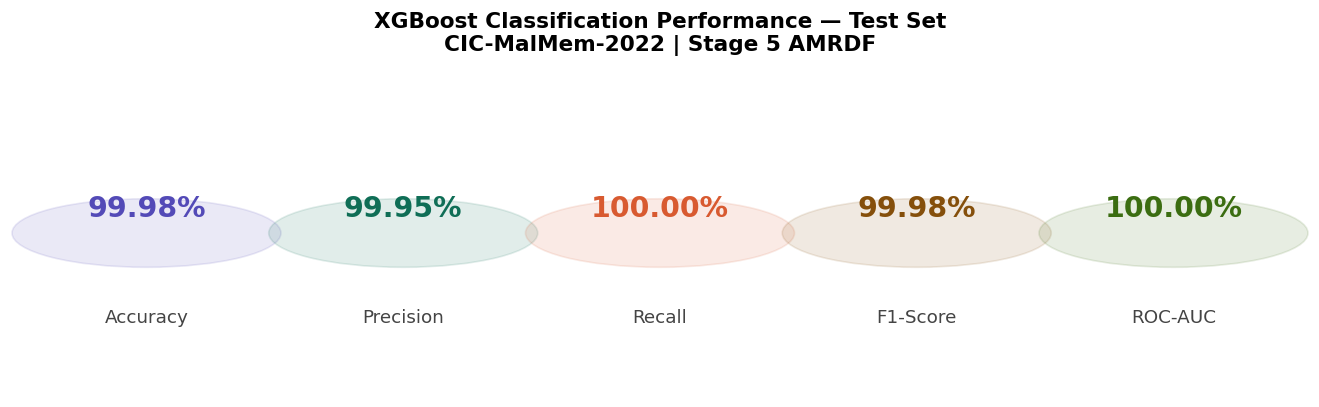

Saved: metrics_summary_card.png


In [5]:
# ── CELL 4 ──────────────────────────────────────────────────────
# PLOT 1 — Metrics summary card
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis('off')
 
metrics_data = {
    'Accuracy'  : (acc,  '#534AB7'),
    'Precision' : (prec, '#0F6E56'),
    'Recall'    : (rec,  '#D85A30'),
    'F1-Score'  : (f1,   '#854F0B'),
    'ROC-AUC'   : (auc,  '#3B6D11'),
}
 
positions = np.linspace(0.08, 0.92, 5)
for i, (metric, (value, color)) in enumerate(metrics_data.items()):
    x = positions[i]
    circle = plt.Circle((x, 0.52), 0.11, color=color,
                         alpha=0.12, transform=ax.transAxes,
                         clip_on=False)
    ax.add_patch(circle)
    ax.text(x, 0.60, f'{value*100:.2f}%',
            ha='center', va='center', fontsize=17,
            fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(x, 0.25, metric,
            ha='center', va='center', fontsize=11,
            color='#444444', transform=ax.transAxes)
 
ax.set_title('XGBoost Classification Performance — Test Set\n'
             'CIC-MalMem-2022 | Stage 5 AMRDF',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'metrics_summary_card.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metrics_summary_card.png")

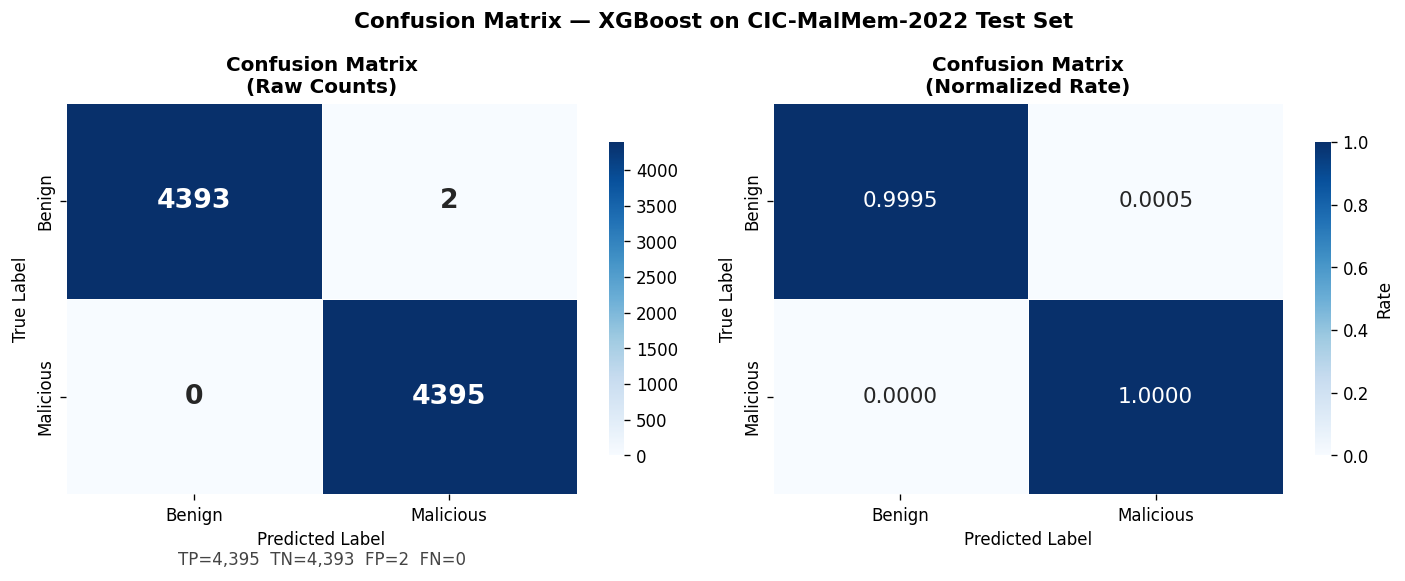

Saved: confusion_matrix.png
  True Positives  (TP) : 4,395
  True Negatives  (TN) : 4,393
  False Positives (FP) : 2  ← False alarms
  False Negatives (FN) : 0  ← Missed attacks


In [6]:
# ── CELL 5 ──────────────────────────────────────────────────────
# PLOT 2 — Confusion Matrix (Raw + Normalized side by side)
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Benign', 'Malicious']
 
# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], xticklabels=labels, yticklabels=labels,
            linewidths=0.5, annot_kws={'size': 16, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix\n(Raw Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
 
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
             f'TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}',
             ha='center', transform=axes[0].transAxes,
             fontsize=10, color='#444444')
 
# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.4f', cmap='Blues',
            ax=axes[1], xticklabels=labels, yticklabels=labels,
            linewidths=0.5, annot_kws={'size': 13},
            cbar_kws={'shrink': 0.8, 'label': 'Rate'})
axes[1].set_title('Confusion Matrix\n(Normalized Rate)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
 
plt.suptitle('Confusion Matrix — XGBoost on CIC-MalMem-2022 Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: confusion_matrix.png")
print(f"  True Positives  (TP) : {tp:,}")
print(f"  True Negatives  (TN) : {tn:,}")
print(f"  False Positives (FP) : {fp:,}  ← False alarms")
print(f"  False Negatives (FN) : {fn:,}  ← Missed attacks")

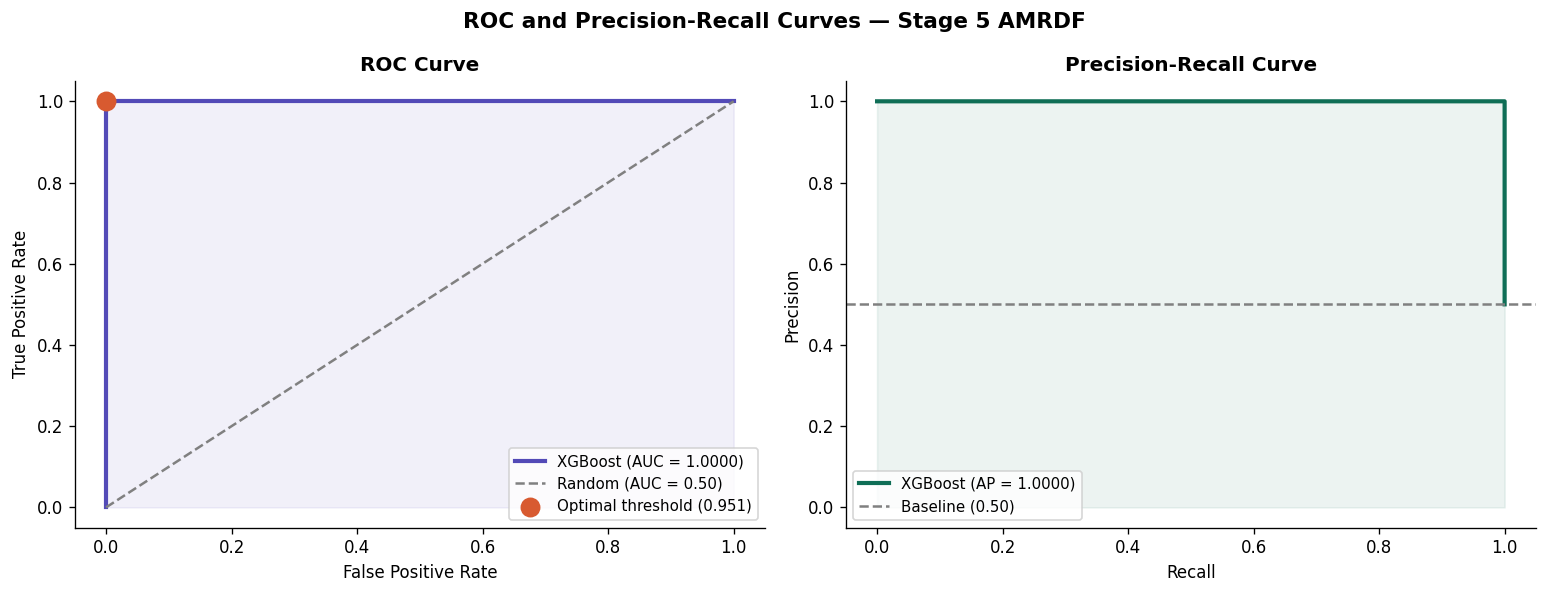

Saved: roc_pr_curves.png


In [7]:
# ── CELL 6 ──────────────────────────────────────────────────────
# PLOT 3 — ROC Curve + Precision-Recall Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_pred_prob)
optimal_idx   = np.argmax(tpr - fpr)
optimal_thresh = roc_thresholds[optimal_idx]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# ROC Curve
axes[0].plot(fpr, tpr, color='#534AB7', lw=2.5,
             label=f'XGBoost (AUC = {auc:.4f})')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#534AB7')
axes[0].plot([0,1],[0,1], '--', color='gray', lw=1.5,
             label='Random (AUC = 0.50)')
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx],
                color='#D85A30', s=120, zorder=5,
                label=f'Optimal threshold ({optimal_thresh:.3f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)
 
# Precision-Recall Curve
axes[1].plot(rec_curve, prec_curve, color='#0F6E56', lw=2.5,
             label=f'XGBoost (AP = {ap:.4f})')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.08, color='#0F6E56')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', lw=1.5,
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(fontsize=9)
 
plt.suptitle('ROC and Precision-Recall Curves — Stage 5 AMRDF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'roc_pr_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_pr_curves.png")

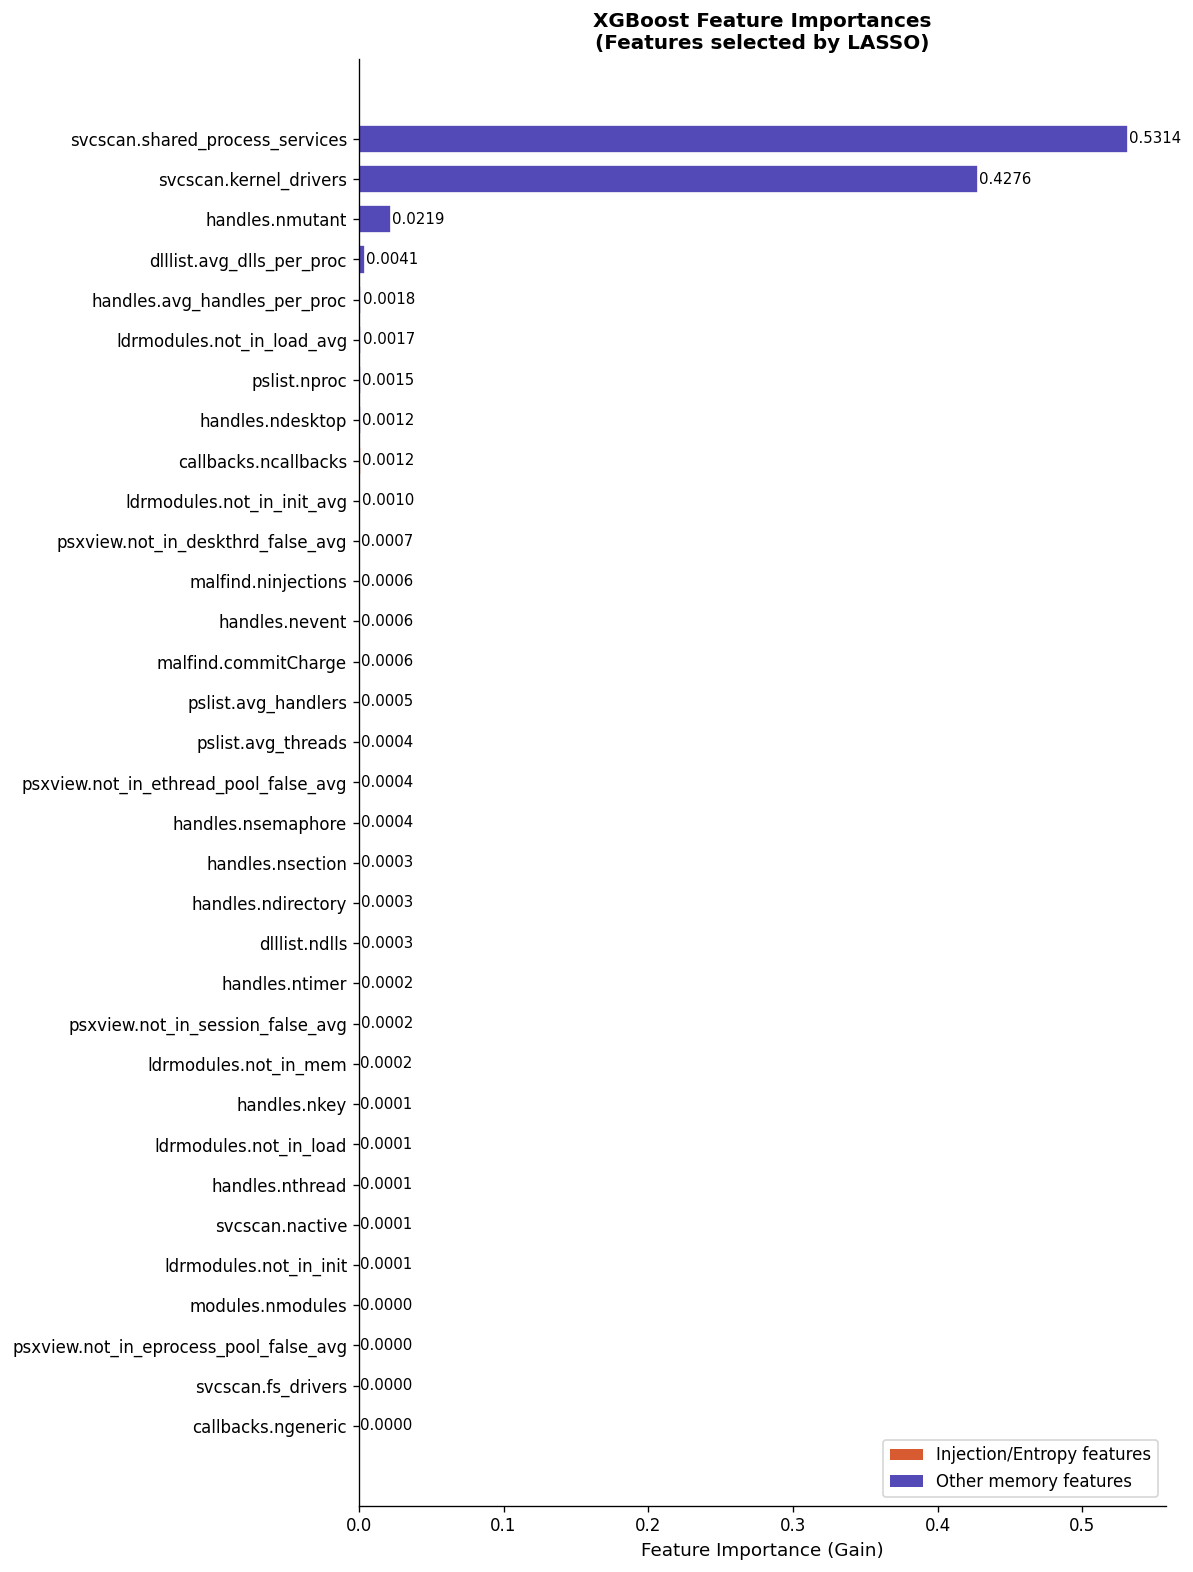

Saved: feature_importance.png


In [8]:
# ── CELL 7 ──────────────────────────────────────────────────────
# PLOT 4 — XGBoost Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_,
                     index=feature_names).sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(10, max(5, len(feat_imp)*0.4)))
colors  = ['#D85A30' if 'inject' in f or 'malfind' in f or 'callback' in f
           else '#534AB7' for f in feat_imp.index]
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=colors, edgecolor='white', height=0.7)
 
for bar in bars:
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}',
            va='center', fontsize=9)
 
legend_elements = [
    mpatches.Patch(facecolor='#D85A30', label='Injection/Entropy features'),
    mpatches.Patch(facecolor='#534AB7', label='Other memory features')
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax.set_title('XGBoost Feature Importances\n(Features selected by LASSO)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

Computing SHAP values (may take 1-2 minutes)...
Standard TreeExplainer failed: could not convert string to float: '[5.000122E-1]'
Trying with model_output='raw' workaround...
Workaround also failed: could not convert string to float: '[5.000122E-1]'
Using Explainer (generic) as final fallback...


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

Computing SHAP values (may take 1-2 minutes)...
Fixed base_score: '[5.000122E-1]' → '5.000122E-1'
Still failing: could not convert string to float: '[5.000122E-1]'
Using KernelExplainer as final fallback (slower but always works)...


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values computed using KernelExplainer fallback!
SHAP values shape: (200, 33, 2)


<Figure size 1320x1980 with 0 Axes>

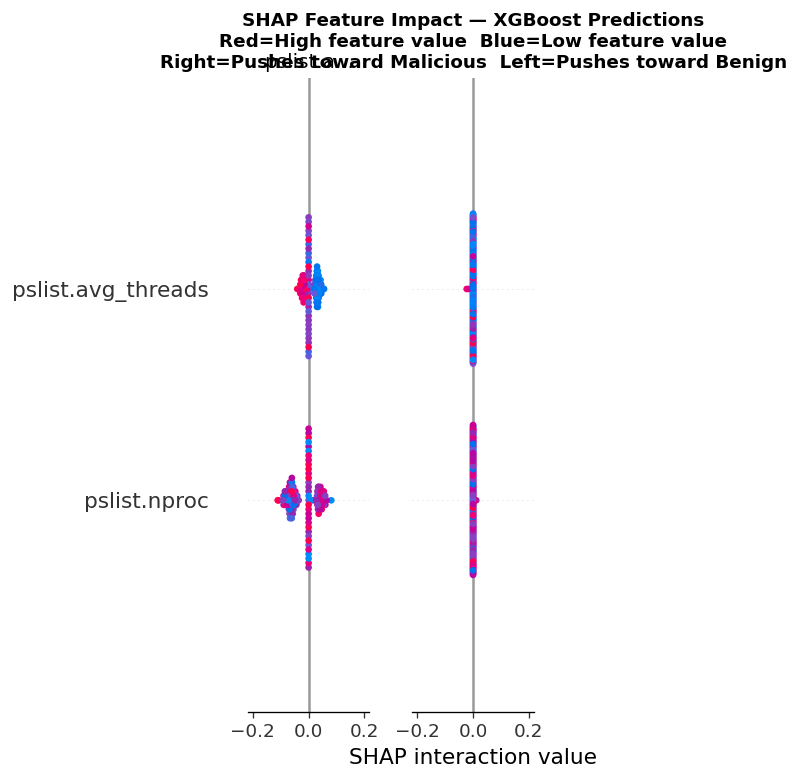

Saved: shap_summary.png


<Figure size 1200x1584 with 0 Axes>

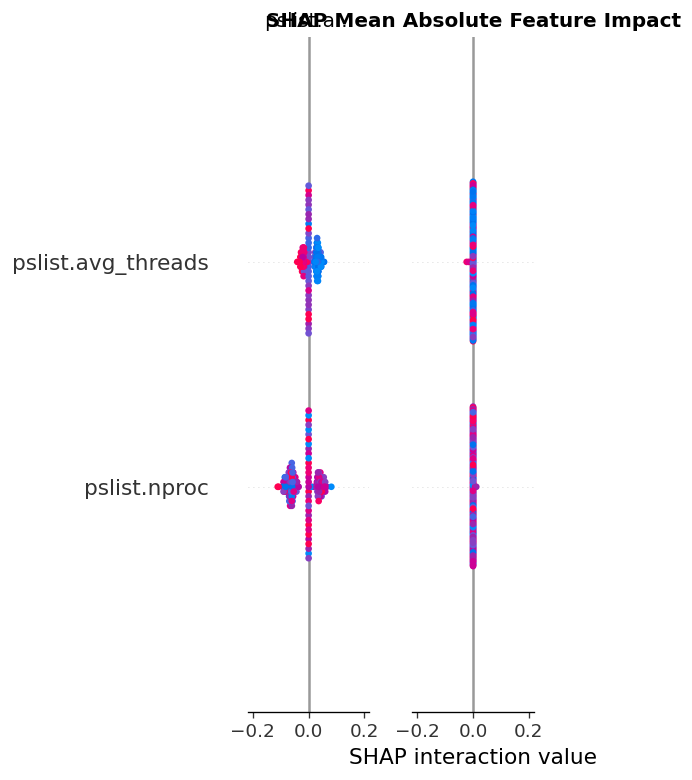

Saved: shap_bar.png

Notebook 07 complete — proceed to 08_dres_score.ipynb


In [11]:
# Cell 9 — SHAP explainability (FIXED for base_score string bug)
print("Computing SHAP values (may take 1-2 minutes)...")

X_test_df = pd.DataFrame(X_test, columns=feature_names)
n_shap    = min(2000, len(X_test))

# ── FIX: Repair the base_score string bug in XGBoost 2.x ──
import json
import copy

def fix_xgboost_base_score(model):
    """Fixes the base_score string-to-float bug in some XGBoost 2.x versions."""
    booster = model.get_booster()
    config  = json.loads(booster.save_config())
    
    try:
        bs = config['learner']['learner_model_param']['base_score']
        if isinstance(bs, str) and bs.startswith('['):
            # Extract the float from string like '[5.000122E-1]'
            clean_val = bs.strip('[]')
            config['learner']['learner_model_param']['base_score'] = clean_val
            booster.load_config(json.dumps(config))
            print(f"Fixed base_score: '{bs}' → '{clean_val}'")
    except (KeyError, Exception) as e:
        print(f"base_score fix not needed or failed: {e}")
    
    return model

xgb_model_fixed = fix_xgboost_base_score(copy.deepcopy(xgb_model))

try:
    explainer   = shap.TreeExplainer(xgb_model_fixed)
    shap_values = explainer.shap_values(X_test_df.iloc[:n_shap])
    print("SHAP values computed successfully with fixed model!")
except Exception as e:
    print(f"Still failing: {e}")
    print("Using KernelExplainer as final fallback (slower but always works)...")
    
    # Sample background data for KernelExplainer (must be small for speed)
    background = shap.sample(X_test_df, 100)
    explainer   = shap.KernelExplainer(
        xgb_model.predict_proba, background)
    n_shap_small = min(200, len(X_test))  # KernelExplainer is slow, use fewer samples
    shap_values_raw = explainer.shap_values(X_test_df.iloc[:n_shap_small])
    shap_values = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw
    n_shap = n_shap_small
    print("SHAP values computed using KernelExplainer fallback!")

print(f"SHAP values shape: {np.array(shap_values).shape}")

# SHAP Summary plot
plt.figure(figsize=(11, max(5, len(feature_names)*0.5)))
shap.summary_plot(shap_values, X_test_df.iloc[:n_shap],
                  show=False, plot_size=None)
plt.title('SHAP Feature Impact — XGBoost Predictions\n'
          'Red=High feature value  Blue=Low feature value\n'
          'Right=Pushes toward Malicious  Left=Pushes toward Benign',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'shap_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

# SHAP bar plot
plt.figure(figsize=(10, max(5, len(feature_names)*0.4)))
shap.summary_plot(shap_values, X_test_df.iloc[:n_shap],
                  plot_type='bar', show=False)
plt.title('SHAP Mean Absolute Feature Impact',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'shap_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar.png")
print("\nNotebook 07 complete — proceed to 08_dres_score.ipynb")